<a href="https://colab.research.google.com/github/ioos/bio_data_guide/blob/main/datasets/SanctSound/05_sanctsound_obis_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!pip install pyobis cartopy -q

Collect data from https://obis.org/dataset/7a4427f6-67ee-4cc1-b95f-3045523420a1

make a plot of the sound receiver location and a circle around the point for `coordinateUncertaintyInMeters`.

This shows the bounds at which a species occurrence might have occurred.

In [7]:
from pyobis import occurrences
import pandas as pd
query = occurrences.search(datasetid='7a4427f6-67ee-4cc1-b95f-3045523420a1')
query.execute() # execute the query

df = pd.DataFrame(query.data['results']) # returns the data of the query

df

,associatedReferences,basisOfRecord,brackish,class,classid,coordinateUncertaintyInMeters,countryCode,date_end,date_mid,date_start,...,superfamilyid,category,gigaclass,gigaclassid,parvphylum,parvphylumid,subfamily,subfamilyid,superclass,superclassid
0,"[1] Collins M.D., A split-step Padé solution f...",MachineObservation,True,Mammalia,1837,3065.0,US,1604966400000,1604966400000,1604966400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[1] Collins M.D., A split-step Padé solution f...",MachineObservation,NaN,Mammalia,1837,83609.0,US,1592438400000,1592438400000,1592438400000,...,148724.0,VU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[1] Collins M.D., A split-step Padé solution f...",MachineObservation,NaN,Mammalia,1837,26382.0,US,1573776000000,1573776000000,1573776000000,...,148724.0,VU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[1] Collins M.D., A split-step Padé solution f...",MachineObservation,NaN,Mammalia,1837,2361.0,US,1573344000000,1573344000000,1573344000000,...,148724.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[1] Collins M.D., A split-step Padé solution f...",MachineObservation,NaN,Mammalia,1837,44328.0,US,1563840000000,1563840000000,1563840000000,...,148724.0,EN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22923,"[1] Collins M.D., A split-step Padé solution f...",MachineObservation,True,Mammalia,1837,2232.0,US,1542758400000,1542758400000,1542758400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22924,"[1] Collins M.D., A split-step Padé solution f...",MachineObservation,NaN,Mammalia,1837,16316.0,US,1600128000000,1600128000000,1600128000000,...,148724.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22925,"[1] Collins M.D., A split-step Padé solution f...",MachineObservation,True,Mammalia,1837,2046.0,US,1587254400000,1587254400000,1587254400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22926,"[1] Collins M.D., A split-step Padé solution f...",MachineObservation,True,Mammalia,1837,2593.0,US,1573948800000,1573948800000,1573948800000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.columns

Index(['associatedReferences', 'basisOfRecord', 'brackish', 'class', 'classid',
       'coordinateUncertaintyInMeters', 'countryCode', 'date_end', 'date_mid',
       'date_start', 'date_year', 'decimalLatitude', 'decimalLongitude',
       'depth', 'eventDate', 'eventID', 'geodeticDatum', 'infraorder',
       'infraorderid', 'infraphylum', 'infraphylumid', 'kingdom', 'kingdomid',
       'marine', 'maximumDepthInMeters', 'megaclass', 'megaclassid',
       'minimumDepthInMeters', 'occurrenceID', 'occurrenceStatus', 'order',
       'orderid', 'phylum', 'phylumid', 'samplingProtocol', 'scientificName',
       'scientificNameID', 'subclass', 'subclassid', 'suborder', 'suborderid',
       'subphylum', 'subphylumid', 'taxonRank', 'vernacularName', 'wrims',
       'id', 'dataset_id', 'node_id', 'dropped', 'absence',
       'originalScientificName', 'aphiaID', 'flags', 'bathymetry',
       'shoredistance', 'sst', 'sss', 'family', 'familyid', 'genus', 'genusid',
       'species', 'speciesid', 'su

In [10]:
df[['decimalLatitude','decimalLongitude','coordinateUncertaintyInMeters']]

,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters
0,42.255080,-70.179047,3065.0
1,33.848900,-120.117100,83609.0
2,42.255530,-70.178973,26382.0
3,33.848880,-120.117000,2361.0
4,33.848900,-120.117500,44328.0
...,...,...,...
22923,42.436838,-70.546958,2232.0
22924,36.797700,-121.975700,16316.0
22925,24.433130,-81.930680,2046.0
22926,31.396417,-80.890400,2593.0


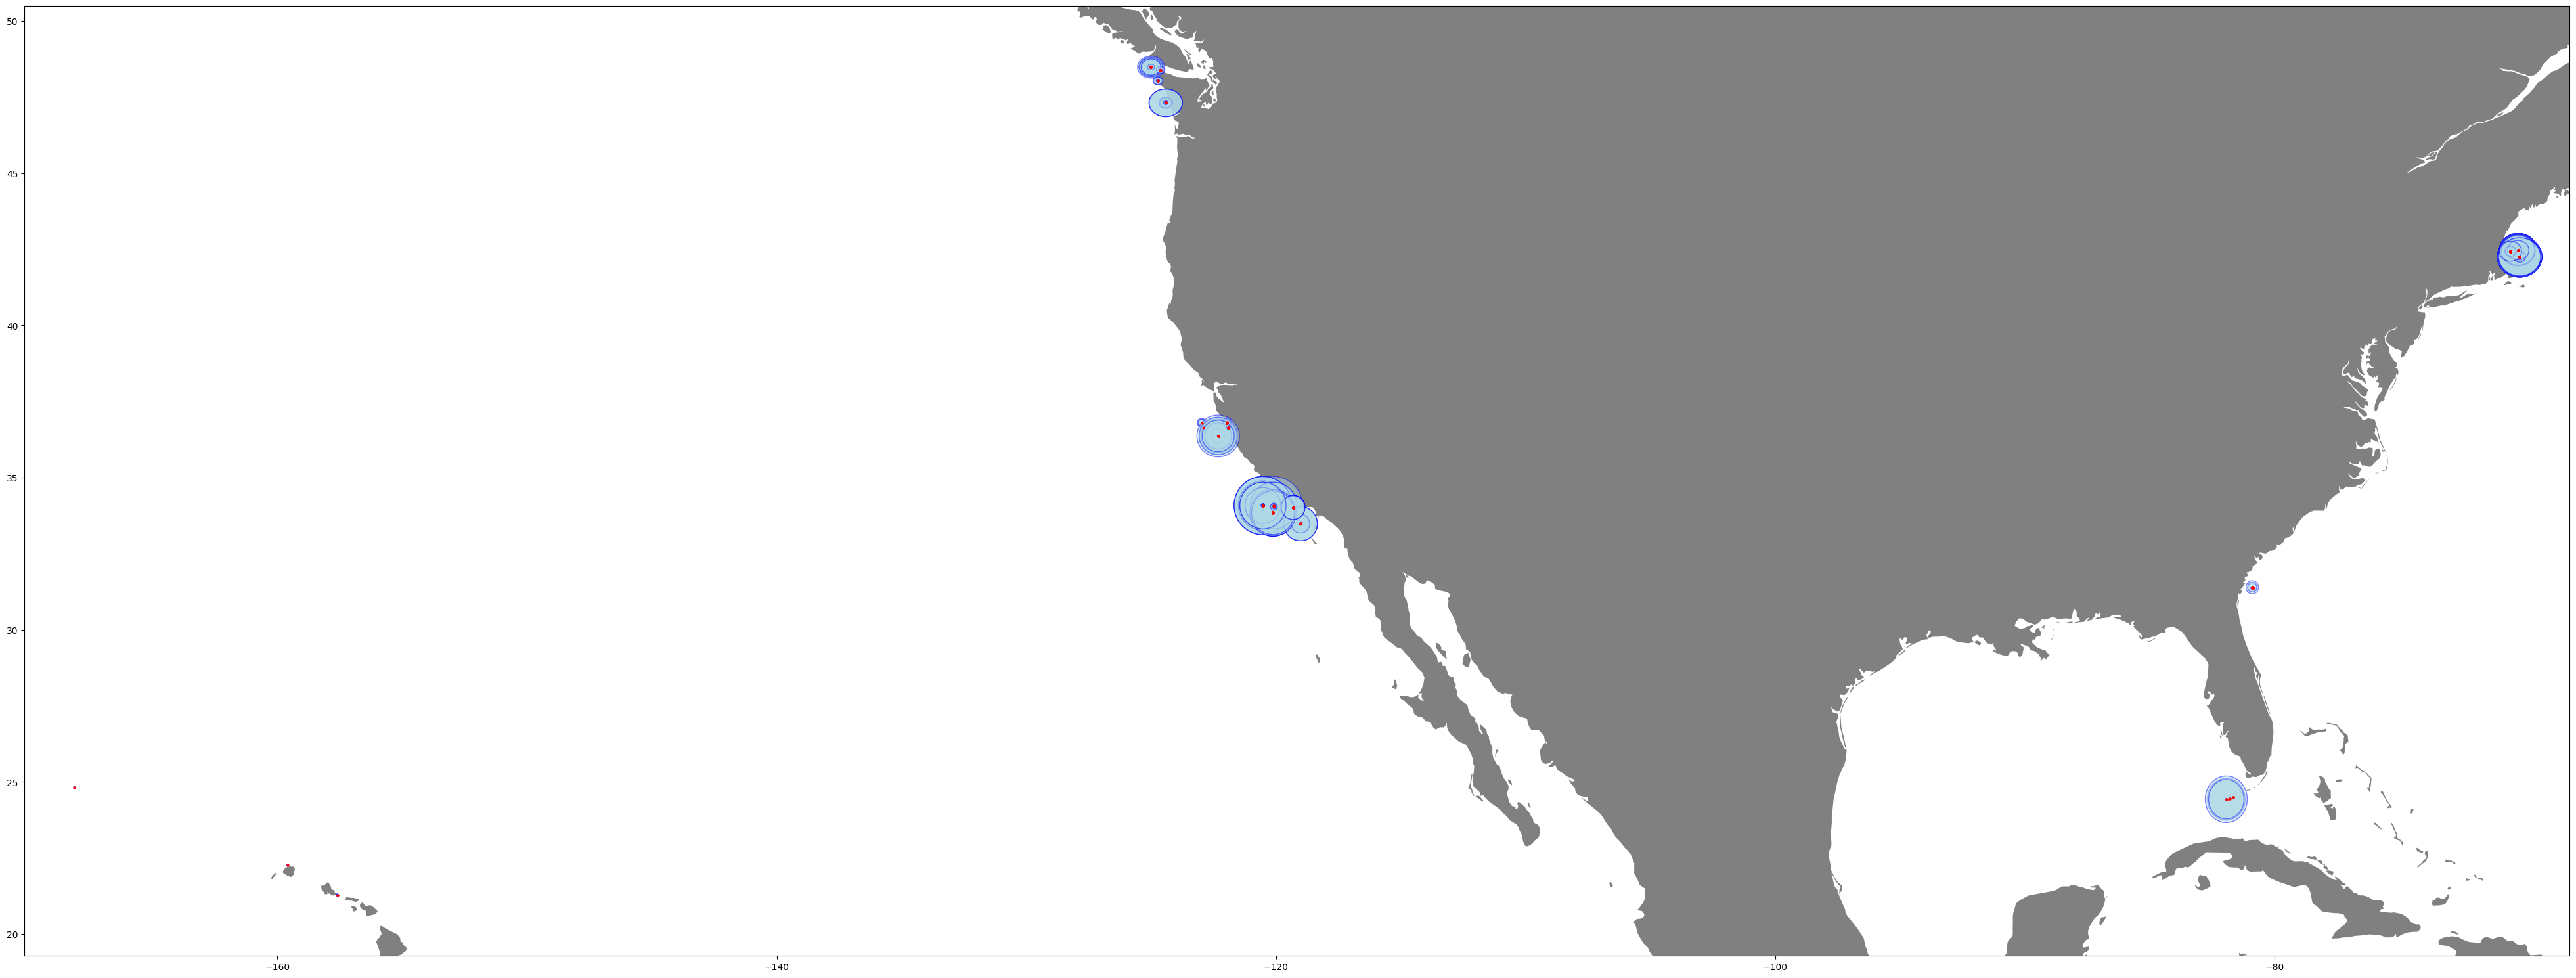

In [22]:
import cartopy.io.shapereader as shpreader
import geopandas as gpd
import shapely.geometry as sgeom
from shapely.ops import unary_union
from shapely.prepared import prep
import matplotlib.pyplot as plt

df = df[['decimalLatitude','decimalLongitude','coordinateUncertaintyInMeters']].drop_duplicates()

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.decimalLongitude, df.decimalLatitude), crs='WGS84')

## Create buffer
gdf_projected = gdf.to_crs(epsg=3857) # convert to crs w/ meters
gdf_buffer = gdf_projected.copy()
gdf_buffer["geometry"] = gdf_buffer.geometry.buffer(gdf_buffer['coordinateUncertaintyInMeters'])
gdf_buffer = gdf_buffer.to_crs(epsg=4326) # convert back to geolocation crs

land_shp_fname = shpreader.natural_earth(resolution='50m',
                                       category='physical', name='land')

land_geom = unary_union(list(shpreader.Reader(land_shp_fname).geometries()))
land = prep(land_geom)

fig, axs = plt.subplots(figsize=(50,50))#ncols=1,nrows=1)

# Make a map:
xlim = ([gdf.total_bounds[0]-2,  gdf.total_bounds[2]+2])
ylim = ([gdf.total_bounds[1]-2,  gdf.total_bounds[3]+2])

axs.set_xlim(xlim)
axs.set_ylim(ylim)

gpd.read_file(land_shp_fname).plot(ax=axs, color="grey")

gdf_buffer.plot(color="lightblue", edgecolor="blue", alpha=0.5, ax=axs)

gdf.plot(ax=axs, color='red', markersize=3)

plt.show()